In [1]:
import pandas as pd
import numpy as np

In [2]:
# Loading the saved unified dataset fresh
# NOT using the 'unified' variable from Task 1 because nulls were already filled there during data quality steps
# loading from CSV ensures we have the original null values intact

path = "E:/Dhara/IVY_ProSchool_project/Python Internship_2026/Apex Dataset/"

unified = pd.read_csv("E:/Dhara/IVY_ProSchool_project/Python Internship_2026/Apex Dataset/unified_production_dataset.csv")

print("Dataset Loaded Successfully")
print(f"Total Rows    : {unified.shape[0]}")
print(f"Total Columns : {unified.shape[1]}")

print("Confirming nulls are present before treatment:")
print(unified.isnull().sum()[unified.isnull().sum() > 0])

Dataset Loaded Successfully
Total Rows    : 12203
Total Columns : 38
Confirming nulls are present before treatment:
operator_id                122
pressure_bar               122
vibration_mm_s             122
oil_temp_c                 154
line_id                    182
area                       182
machine_type               182
commissioned_date          182
rated_speed_rpm            182
rated_pressure_bar         182
sensor_pack                182
criticality                182
vendor_type                122
role                       122
skill_level                122
experience_years           122
joining_date               122
home_location              122
training_hours_last_90d    122
dtype: int64


In [3]:
#Count Missing Values
missing_count = unified.isnull().sum()
print(missing_count)

source_system                0
prod_date                    0
shift_code                   0
machine_id                   0
operator_id                122
product_code                 0
batch_id                     0
planned_units                0
good_units                   0
downtime_min                 0
changeover_min               0
overtime_min                 0
speed_rpm                    0
pressure_bar               122
vibration_mm_s             122
oil_temp_c                 154
torque_nm                    0
ambient_temp_c               0
ambient_humidity_pct         0
actual_cycle_time_sec        0
scrap_pct                    0
rework_min                   0
defect_flag                  0
line_id                    182
area                       182
machine_type               182
commissioned_date          182
rated_speed_rpm            182
rated_pressure_bar         182
sensor_pack                182
criticality                182
vendor_type                122
role    

In [4]:
#Duplicate Records Check
print("DUPLICATE RECORDS CHECK")
print(f"Total Rows Before : {unified.shape[0]}")

# Count duplicates
duplicate_count = unified.duplicated().sum()
print(f"Duplicate Rows Found : {duplicate_count}")


DUPLICATE RECORDS CHECK
Total Rows Before : 12203
Duplicate Rows Found : 0


In [5]:
# If duplicates exist, show them and remove
if duplicate_count > 0:
    print("\nSample Duplicate Rows:")
    print(unified[unified.duplicated(keep=False)].head(10))
    
    unified.drop_duplicates(inplace=True)
    unified.reset_index(drop=True, inplace=True)
    
    print(f"\nDuplicates Removed Successfully!")
    print(f"Total Rows After  : {unified.shape[0]}")
else:
    print("No duplicate records found-No action needed.")

No duplicate records found-No action needed.


In [6]:
#Calculate Percentage
missing_pct = (unified.isnull().sum() / len(unified) * 100).round(2)
print(missing_pct)

source_system              0.00
prod_date                  0.00
shift_code                 0.00
machine_id                 0.00
operator_id                1.00
product_code               0.00
batch_id                   0.00
planned_units              0.00
good_units                 0.00
downtime_min               0.00
changeover_min             0.00
overtime_min               0.00
speed_rpm                  0.00
pressure_bar               1.00
vibration_mm_s             1.00
oil_temp_c                 1.26
torque_nm                  0.00
ambient_temp_c             0.00
ambient_humidity_pct       0.00
actual_cycle_time_sec      0.00
scrap_pct                  0.00
rework_min                 0.00
defect_flag                0.00
line_id                    1.49
area                       1.49
machine_type               1.49
commissioned_date          1.49
rated_speed_rpm            1.49
rated_pressure_bar         1.49
sensor_pack                1.49
criticality                1.49
vendor_t

In [7]:
#Classify Columns
#Numerical Variables :- numbers, measurements 
#planned_units, good_units, speed_rpm, pressure_bar, vibration_mm_s, oil_temp_c

numerical_cols = unified.select_dtypes(include=["int64","Int64","float64"]).columns.tolist()
print(f"Numerical Variables ({len(numerical_cols)}) :")
for col in numerical_cols:
    print(f"  {col}")

Numerical Variables (20) :
  planned_units
  good_units
  downtime_min
  changeover_min
  overtime_min
  speed_rpm
  pressure_bar
  vibration_mm_s
  oil_temp_c
  torque_nm
  ambient_temp_c
  ambient_humidity_pct
  actual_cycle_time_sec
  scrap_pct
  rework_min
  defect_flag
  rated_speed_rpm
  rated_pressure_bar
  experience_years
  training_hours_last_90d


In [8]:
#Categorical Variables :- labels, categories
#source_system, shift_code, machine_id, product_code, area, criticality, skill_level

categorical_cols = unified.select_dtypes(include=["object","datetime64[ns]"]).columns.tolist()
print(f"Categorical Variables ({len(categorical_cols)}) :")
for col in categorical_cols:
    print(f" {col}")

Categorical Variables (18) :
 source_system
 prod_date
 shift_code
 machine_id
 operator_id
 product_code
 batch_id
 line_id
 area
 machine_type
 commissioned_date
 sensor_pack
 criticality
 vendor_type
 role
 skill_level
 joining_date
 home_location


In [9]:
#Treat the Missing Values
# Numerical:- Median
for col in numerical_cols:
    null_before = unified[col].isnull().sum()
    median_val  = unified[col].median()
    
    if null_before > 0:
        unified[col].fillna(median_val, inplace=True)
        null_after = unified[col].isnull().sum()
        print(f"  {col}")
        print(f" Nulls Before : {null_before}")
        print(f" Filled With  : {median_val} (median)")
        print(f" Nulls After  : {null_after}")
        print()
    else:
        print(f"  {col} :- No nulls found - skipped")  # NOW you will see output either way

  planned_units :- No nulls found - skipped
  good_units :- No nulls found - skipped
  downtime_min :- No nulls found - skipped
  changeover_min :- No nulls found - skipped
  overtime_min :- No nulls found - skipped
  speed_rpm :- No nulls found - skipped
  pressure_bar
 Nulls Before : 122
 Filled With  : 9.8 (median)
 Nulls After  : 0

  vibration_mm_s
 Nulls Before : 122
 Filled With  : 3.08 (median)
 Nulls After  : 0

  oil_temp_c
 Nulls Before : 154
 Filled With  : 68.0 (median)
 Nulls After  : 0

  torque_nm :- No nulls found - skipped
  ambient_temp_c :- No nulls found - skipped
  ambient_humidity_pct :- No nulls found - skipped
  actual_cycle_time_sec :- No nulls found - skipped
  scrap_pct :- No nulls found - skipped
  rework_min :- No nulls found - skipped
  defect_flag :- No nulls found - skipped
  rated_speed_rpm
 Nulls Before : 182
 Filled With  : 3315.0 (median)
 Nulls After  : 0

  rated_pressure_bar
 Nulls Before : 182
 Filled With  : 9.5 (median)
 Nulls After  : 0

  ex

In [10]:
#categorical - mode
categorical_cols = unified.select_dtypes(include=["object"]).columns.tolist()

print("CATEGORICAL COLUMNS :- FILLED WITH MODE")
print(f"Total Categorical Columns : {len(categorical_cols)}")
print(f"Columns with Nulls        : {sum(unified[col].isnull().sum() > 0 for col in categorical_cols)}")
print()

for col in categorical_cols:
    null_before = unified[col].isnull().sum()
    if null_before > 0:
        mode_val = unified[col].mode()[0]
        unified[col].fillna(mode_val, inplace=True)
        null_after = unified[col].isnull().sum()
        print(f"  {col}")
        print(f" Nulls Before : {null_before}")
        print(f" Filled With  : {mode_val} (mode)")
        print(f" Nulls After  : {null_after}")
        print()

if sum(unified[col].isnull().sum() > 0 for col in categorical_cols) == 0:
    print("  No nulls found in any categorical column!")


CATEGORICAL COLUMNS :- FILLED WITH MODE
Total Categorical Columns : 18
Columns with Nulls        : 12

  operator_id
 Nulls Before : 122
 Filled With  : OP-0041 (mode)
 Nulls After  : 0

  line_id
 Nulls Before : 182
 Filled With  : LINE-D (mode)
 Nulls After  : 0

  area
 Nulls Before : 182
 Filled With  : HeatTreat (mode)
 Nulls After  : 0

  machine_type
 Nulls Before : 182
 Filled With  : Heat Treatment (mode)
 Nulls After  : 0

  commissioned_date
 Nulls Before : 182
 Filled With  : 2020-08-30 (mode)
 Nulls After  : 0

  sensor_pack
 Nulls Before : 182
 Filled With  : S2 (mode)
 Nulls After  : 0

  criticality
 Nulls Before : 182
 Filled With  : medium (mode)
 Nulls After  : 0

  vendor_type
 Nulls Before : 122
 Filled With  : Atlas Copco (mode)
 Nulls After  : 0

  role
 Nulls Before : 122
 Filled With  : Maintenance Tech (mode)
 Nulls After  : 0

  skill_level
 Nulls Before : 122
 Filled With  : L2 (mode)
 Nulls After  : 0

  joining_date
 Nulls Before : 122
 Filled With  : 2021

In [11]:
# Final check :- confirm 0 nulls remain after treatment
print("FINAL VERIFICATION")

remaining = unified.isnull().sum().sum()
print(f"Total Remaining Nulls : {remaining}")
if remaining == 0:
    print("All missing values treated successfully")

FINAL VERIFICATION
Total Remaining Nulls : 0
All missing values treated successfully


# EDA

In [12]:
# Importing libraries needed for graphs and charts
import matplotlib.pyplot as plt        # for drawing graphs
import matplotlib.patches as mpatches  # for legend colour boxes
import seaborn as sns                  # for beautiful graphs
import warnings
warnings.filterwarnings('ignore')      # hide unnecessary warnings

# Set a clean graph style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

print("Libraries Imported")

Libraries Imported


In [13]:
# number columns to study
numerical_cols = [
    'planned_units', 'good_units', 'downtime_min', 'changeover_min',
    'overtime_min', 'speed_rpm', 'pressure_bar', 'vibration_mm_s',
    'oil_temp_c', 'torque_nm', 'ambient_temp_c', 'ambient_humidity_pct',
    'actual_cycle_time_sec', 'scrap_pct', 'rework_min',
    'experience_years', 'training_hours_last_90d']

# category (text) columns to study
categorical_cols_eda = [
    'shift_code', 'area', 'machine_type', 'criticality',
    'vendor_type', 'skill_level', 'role', 'source_system']

In [14]:
# this is what we want to PREDICT
target = 'scrap_pct'

print(f"Number Columns : {len(numerical_cols)}")
print(f"Category Columns : {len(categorical_cols_eda)}")
print(f"Target Column  : {target}")

Number Columns : 17
Category Columns : 8
Target Column  : scrap_pct


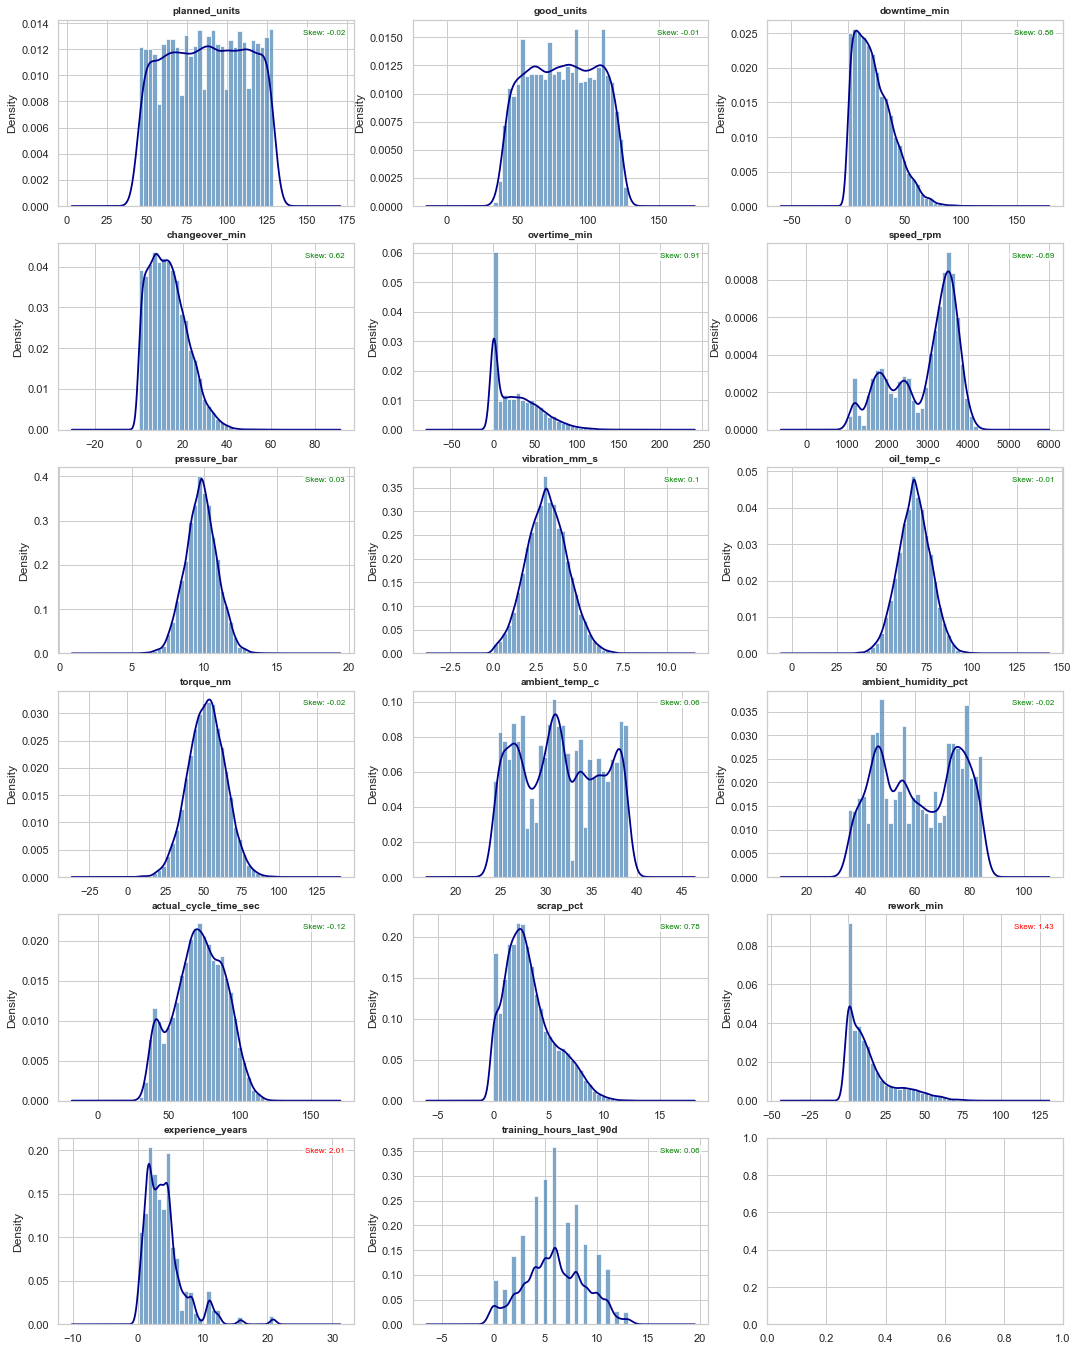

In [15]:
#UNIVARIATE ANALYSIS - Histogram + KDE (Number Columns)
# UNIVARIATE = studying ONE column at a time
# Histogram shows the SHAPE of data — is it balanced or skewed? KDE (curved line) shows the smooth version of the histogram

# Skew value tells us:
# Near 0 = balanced  (GOOD) :- shown in GREEN
# Above 1  = right-skewed :- shown in RED  (has high-value outliers)
# Below -1 = left-skewed :- shown in RED  (has low-value outliers)

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax   = axes[i]
    data = unified[col].dropna()
    skew = round(data.skew(), 2)

    # draw histogram
    ax.hist(data, bins=30, color='steelblue',
            alpha=0.7, edgecolor='white', density=True)
    # draw smooth KDE line on top
    data.plot(kind='kde', ax=ax, color='darkblue', linewidth=1.8)

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel("Density")

    # skew label — red if problem, green if fine
    color = 'red' if abs(skew) > 1 else 'green'
    ax.text(0.97, 0.95, f"Skew: {skew}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

In [16]:
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Analysis — Histogram + KDE (Number Columns)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nResults from YOUR Data:")
print("rework_min : Skew = 1.43 - heavily skewed")
print("experience_years : Skew = 2.01 -heavily skewed")
print("overtime_min : Skew = 0.91 - mild skew")
print("downtime_min : Skew = 0.86 - mild skew")
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Analysis — Histogram + KDE (Number Columns)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nResults from YOUR Data:")
print("rework_min : Skew = 1.43 - heavily skewed")
print("experience_years : Skew = 2.01 -heavily skewed")
print("overtime_min : Skew = 0.91 - mild skew")
print("downtime_min : Skew = 0.86 - mild skew")
print("All others : Skew near 0 - balanced")

<Figure size 432x288 with 0 Axes>


Results from YOUR Data:
rework_min : Skew = 1.43 - heavily skewed
experience_years : Skew = 2.01 -heavily skewed
overtime_min : Skew = 0.91 - mild skew
downtime_min : Skew = 0.86 - mild skew


<Figure size 432x288 with 0 Axes>


Results from YOUR Data:
rework_min : Skew = 1.43 - heavily skewed
experience_years : Skew = 2.01 -heavily skewed
overtime_min : Skew = 0.91 - mild skew
downtime_min : Skew = 0.86 - mild skew
All others : Skew near 0 - balanced


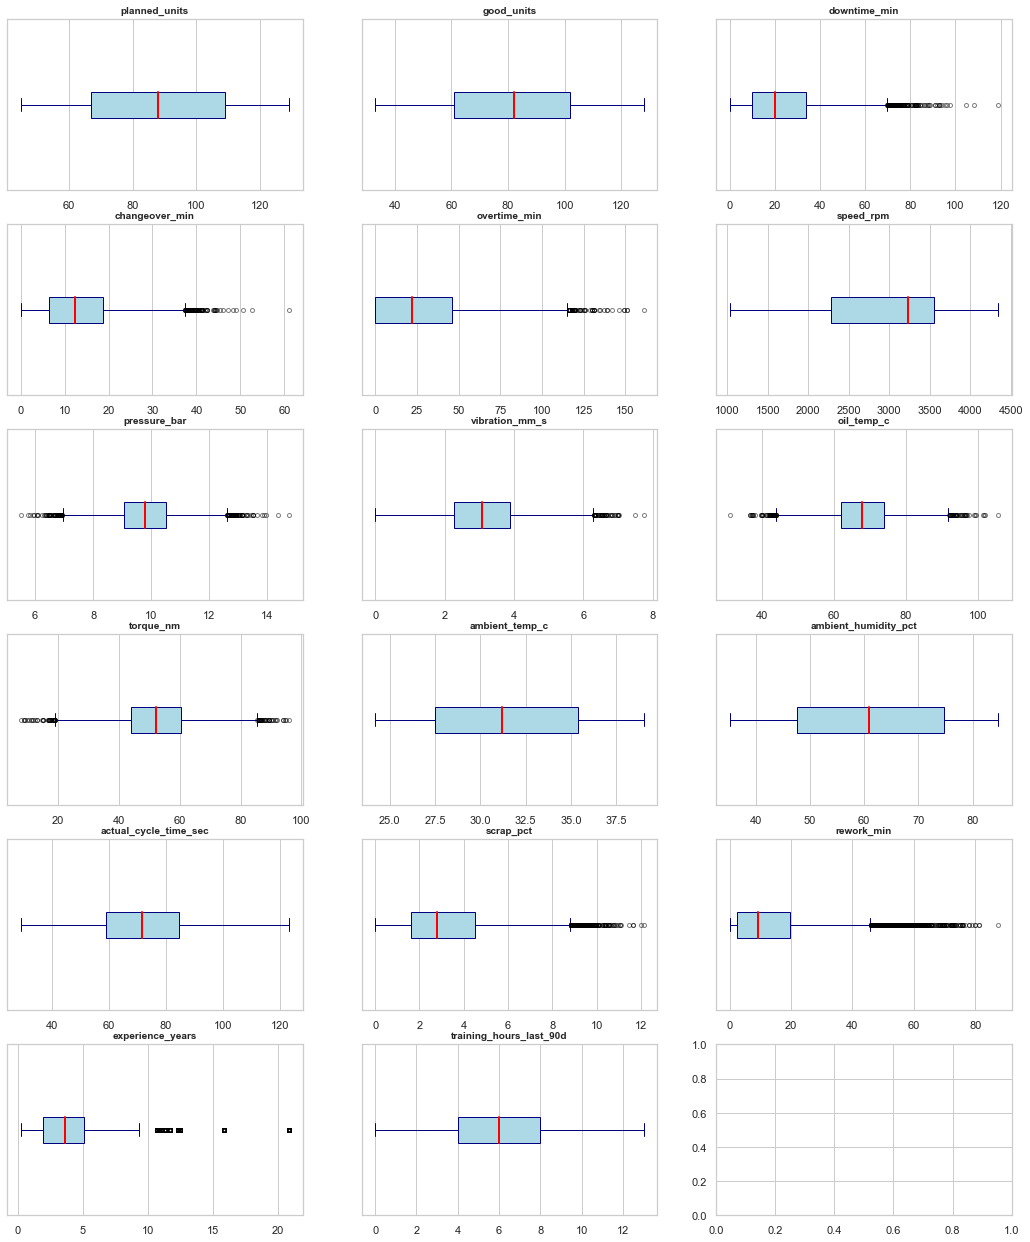

In [17]:
# Box plot shows SPREAD of data and highlights OUTLIERS as dots
# How to read a box plot:
# Red line in the middle = Median (middle value of all data)
# Left edge of box = Q1 (25% of data is below this)
# Right edge of box = Q3 (75% of data is below this)
# Lines extending out = normal range
# Dots outside the lines = OUTLIERS

fig, axes = plt.subplots(6, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    ax.boxplot(unified[col].dropna(),
               vert         = False,
               patch_artist = True,
               boxprops     = dict(facecolor='lightblue', color='navy'),
               medianprops  = dict(color='red', linewidth=2),
               whiskerprops = dict(color='navy'),
               capprops     = dict(color='navy'),
               flierprops   = dict(marker='o', color='orange',
                                   markersize=4, alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_yticks([])

In [18]:
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Analysis — Box Plots  (Orange dots = Outliers)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Orange dots visible in: rework_min, experience_years, scrap_pct,")
print("downtime_min, pressure_bar, oil_temp_c, and more")

<Figure size 432x288 with 0 Axes>


 Orange dots visible in: rework_min, experience_years, scrap_pct,
downtime_min, pressure_bar, oil_temp_c, and more


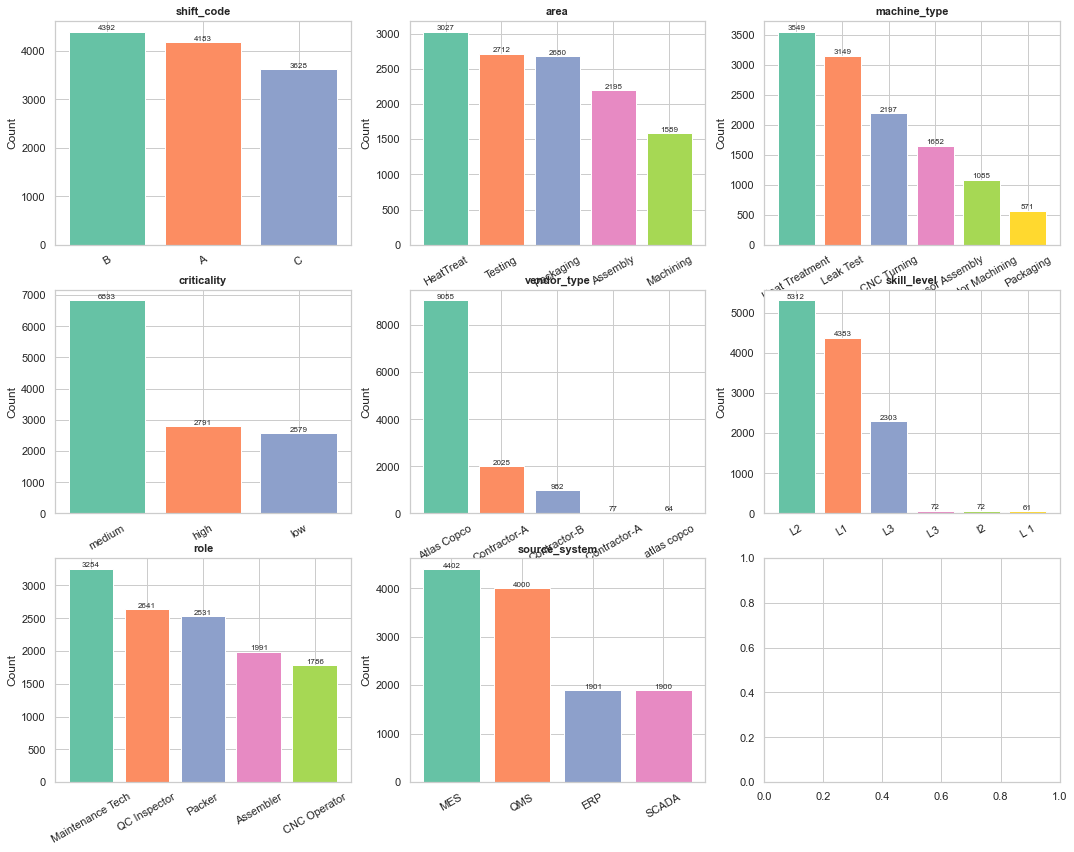

In [19]:
# Bar chart shows how many rows belong to each category
# Example: How many batches were in Shift A vs B vs C?

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_eda):
    ax     = axes[i]
    vc     = unified[col].value_counts()
    colors = sns.color_palette("Set2", len(vc))

    bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)

    # show count on top of each bar
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=8)


In [20]:
for j in range(len(categorical_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Analysis — Category Columns (Frequency Count)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Results from YOUR Data:")
print(" shift_code : B=4392, A=4183, C=3628  (fairly balanced)")
print(" area : HeatTreat most common (3027 rows)")
print(" criticality : medium=6833, high=2791, low=2579")
print(" vendor_type : Atlas Copco dominates (9055 rows)")
print(" skill_level : L2 most common (5312 rows)")

<Figure size 432x288 with 0 Axes>


 Results from YOUR Data:
 shift_code : B=4392, A=4183, C=3628  (fairly balanced)
 area : HeatTreat most common (3027 rows)
 criticality : medium=6833, high=2791, low=2579
 vendor_type : Atlas Copco dominates (9055 rows)
 skill_level : L2 most common (5312 rows)


In [21]:
#This table shows min, max, mean, median for every number column + skewness (shape) and kurtosis 
#how peaked/flat the distribution is

desc = unified[numerical_cols].describe().T
desc['skewness'] = unified[numerical_cols].skew().round(2)
desc['kurtosis'] = unified[numerical_cols].kurtosis().round(2)
desc = desc.round(2)

print("DESCRIPTIVE STATISTICS - ALL NUMBER COLUMNS")
print(desc.to_string())

DESCRIPTIVE STATISTICS - ALL NUMBER COLUMNS
                           count     mean     std      min      25%      50%      75%      max  skewness  kurtosis
planned_units            12203.0    87.53   24.43    45.00    67.00    88.00   109.00   129.00     -0.02     -1.18
good_units               12203.0    81.79   23.83    33.00    61.00    82.00   102.00   128.00     -0.01     -1.15
downtime_min             12203.0    23.26   16.75     0.00     9.80    20.20    33.70   118.90      0.86      0.50
changeover_min           12203.0    13.20    8.54     0.00     6.40    12.30    18.80    61.10      0.62      0.03
overtime_min             12203.0    27.63   27.41     0.00     0.00    22.00    46.00   161.00      0.91      0.30
speed_rpm                12203.0  2918.83  797.39  1031.00  2280.50  3233.00  3548.00  4345.00     -0.69     -0.80
pressure_bar             12203.0     9.79    1.08     5.50     9.08     9.80    10.50    14.76      0.03      0.14
vibration_mm_s           12203.0    

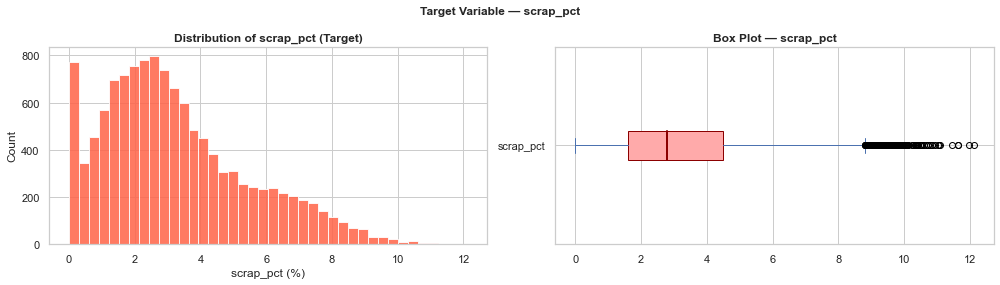

Mean : 3.24%
Median : 2.80%
Std Dev: 2.22
Skew : 0.78  (slightly right-skewed)
Outliers in scrap_pct : 184 rows (1.51%)


In [22]:
#Target Column Overview (scrap_pct)
# Before comparing other columns with our target,let's first understand scrap_pct itself
# scrap_pct = % of production that was wasted/scrapped
# Higher = more waste = worse quality

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(unified['scrap_pct'], bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title("Distribution of scrap_pct (Target)", fontweight='bold')
axes[0].set_xlabel("scrap_pct (%)")
axes[0].set_ylabel("Count")

unified['scrap_pct'].plot(
    kind='box', ax=axes[1], vert=False, patch_artist=True,
    boxprops    = dict(facecolor='#FFAAAA', color='darkred'),
    medianprops = dict(color='darkred', linewidth=2))
axes[1].set_title("Box Plot — scrap_pct", fontweight='bold')

plt.suptitle("Target Variable — scrap_pct", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean : {unified['scrap_pct'].mean():.2f}%")
print(f"Median : {unified['scrap_pct'].median():.2f}%")
print(f"Std Dev: {unified['scrap_pct'].std():.2f}")
print(f"Skew : {unified['scrap_pct'].skew():.2f}  (slightly right-skewed)")
print(f"Outliers in scrap_pct : 184 rows (1.51%)")

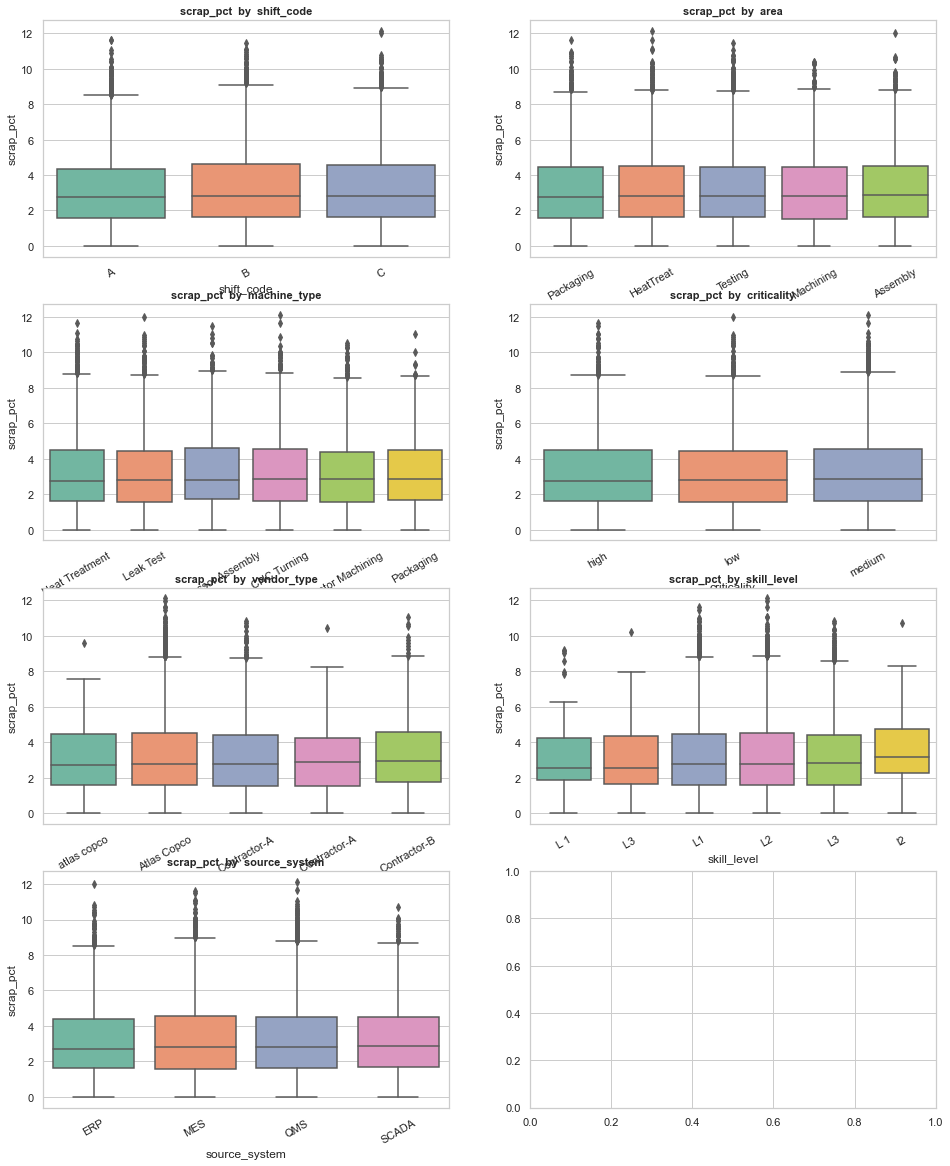

In [23]:
# This shows: does scrap_pct change depending on the category? - Box Plot (Category Columns vs scrap_pct)
# Example: Does Shift A have more scrap than Shift B?
# Boxes sorted from LOW scrap to HIGH scrap (left to right)

cat_target_cols = [
    'shift_code', 'area', 'machine_type', 'criticality',
    'vendor_type', 'skill_level', 'source_system']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_target_cols):
    ax    = axes[i]
    order = (unified.groupby(col)['scrap_pct']
                     .median()
                     .sort_values()
                     .index)
    sns.boxplot(data=unified, x=col, y='scrap_pct',
                order=order, palette='Set2', ax=ax)
    ax.set_title(f"scrap_pct  by  {col}", fontweight='bold', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("scrap_pct")
    ax.tick_params(axis='x', rotation=30)

In [24]:
for j in range(len(cat_target_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate Analysis — Category Columns vs scrap_pct",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Higher box = that category has MORE scrap on average")
print(" Wider box = that category has INCONSISTENT scrap levels")

<Figure size 432x288 with 0 Axes>

 Higher box = that category has MORE scrap on average
 Wider box = that category has INCONSISTENT scrap levels


In [25]:
# OUTLIER = a value that is unusually too HIGH or too LOW - IQR Method (most common way to find outliers):
# Step 1 : Q1 = value at 25% mark of the data
# Step 2 : Q3 = value at 75% mark of the data
# Step 3 : IQR = Q3 - Q1  (this is the middle 50% range)
# Step 4 : Lower Fence = Q1 - (1.5 × IQR):-anything below = outlier
# Step 5 : Upper Fence = Q3 + (1.5 × IQR):-anything above = outlier

outlier_summary = []

for col in numerical_cols:
    Q1    = unified[col].quantile(0.25)
    Q3    = unified[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((unified[col] < lower) | (unified[col] > upper)).sum()
    pct   = round(n_out / len(unified) * 100, 2)

    outlier_summary.append({
        'Column'      : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'Lower Fence' : round(lower, 2),
        'Upper Fence' : round(upper, 2),
        'Outliers'    : n_out,
        'Outlier %'   : pct })

In [26]:
outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)

print("OUTLIER DETECTION REPORT - IQR METHOD")

print(outlier_df.to_string(index=False))

print("\n Columns WITH Outliers in YOUR Data:")
print(" rework_min : 742 outliers  (6.08%)  -: most")
print("experience_years : 734  outliers  (6.01%)")
print("scrap_pct : 184  outliers (1.51%)  -: our target!")
print("downtime_min : 143 outliers (1.17%)")
print("pressure_bar : 131 outliers (1.07%)")
print("oil_temp_c : 92 outliers  (0.75%)")
print("changeover_min : 79 outliers  (0.65%)")
print("torque_nm : 72 outliers (0.59%)")
print("overtime_min : 57 outliers (0.47%)")
print("vibration_mm_s : 46 outliers (0.38%)")
print("Columns with NO outliers:")
print("planned_units, good_units, speed_rpm, ambient_temp_c,")
print("ambient_humidity_pct, actual_cycle_time_sec, training_hours_last_90d")

OUTLIER DETECTION REPORT - IQR METHOD
                 Column      Q1      Q3     IQR  Lower Fence  Upper Fence  Outliers  Outlier %
             rework_min    2.40   19.80   17.40       -23.70        45.90       742       6.08
       experience_years    1.90    5.10    3.20        -2.90         9.90       734       6.01
              scrap_pct    1.60    4.49    2.88        -2.73         8.81       184       1.51
           downtime_min    9.80   33.70   23.90       -26.05        69.55       143       1.17
           pressure_bar    9.08   10.50    1.42         6.95        12.63       131       1.07
             oil_temp_c   62.00   74.00   12.00        44.00        92.00        92       0.75
         changeover_min    6.40   18.80   12.40       -12.20        37.40        79       0.65
              torque_nm   43.90   60.50   16.60        19.00        85.40        72       0.59
           overtime_min    0.00   46.00   46.00       -69.00       115.00        57       0.47
         vib

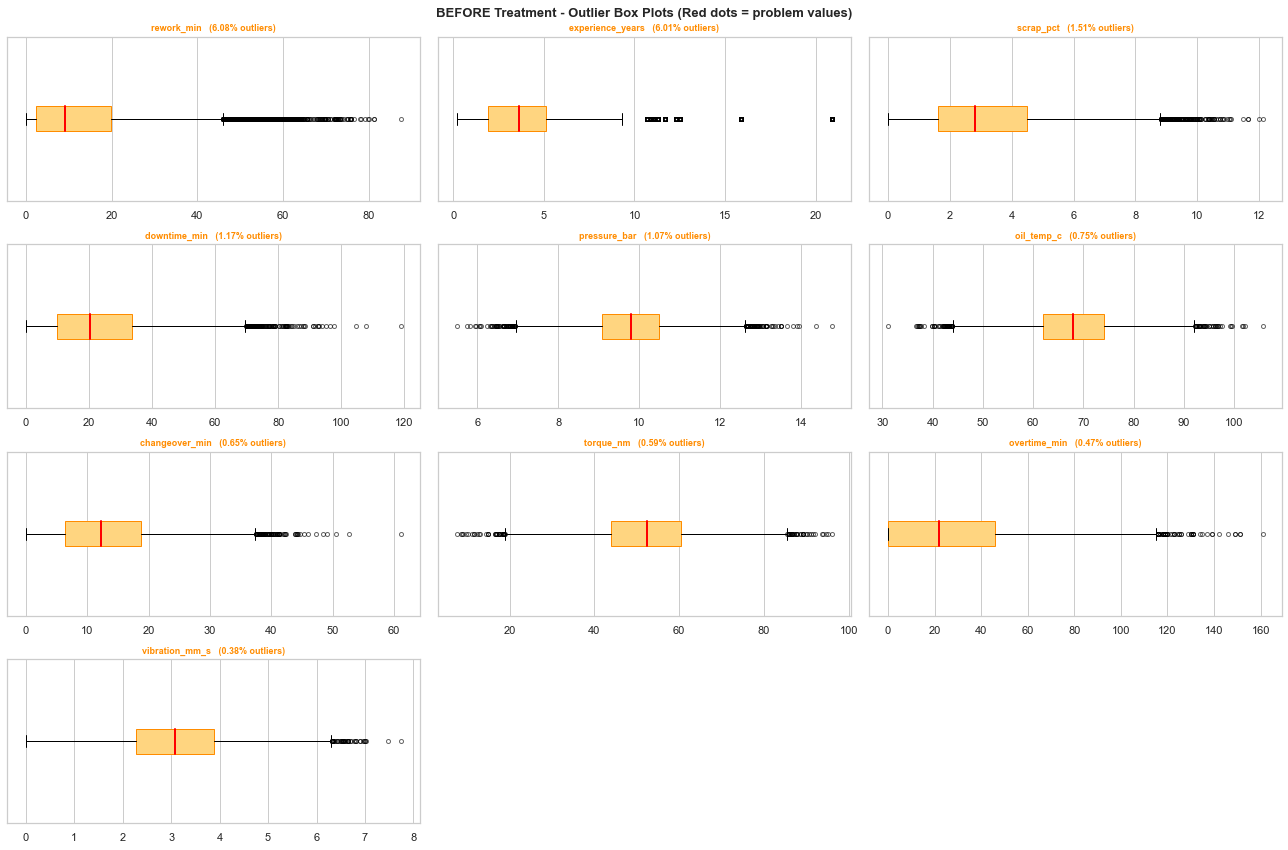

In [27]:
#Box Plots BEFORE Treatment
#Visually see the outlier dots BEFORE we fix them Orange dots = outlier values that need treatment

cols_with_outliers = outlier_df[outlier_df['Outlier %'] > 0]['Column'].tolist()

n = len(cols_with_outliers)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    ax  = axes[i]
    pct = outlier_df[outlier_df['Column'] == col]['Outlier %'].values[0]
    ax.boxplot(unified[col].dropna(), vert=False, patch_artist=True,
               boxprops    = dict(facecolor='#FFD580', color='darkorange'),
               medianprops = dict(color='red', linewidth=2),
               flierprops  = dict(marker='o', color='red',
                                  markersize=4, alpha=0.6))
    ax.set_title(f"{col}   ({pct}% outliers)",
                 fontweight='bold', fontsize=9, color='darkorange')
    ax.set_yticks([])

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BEFORE Treatment - Outlier Box Plots (Red dots = problem values)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# TREATMENT METHOD : Capping (also called Winsorization)

# What capping does:
#   If a value is ABOVE Upper Fence :- replace it WITH Upper Fence value
#   If a value is BELOW Lower Fence :- replace it WITH Lower Fence value

# Why NOT delete the rows?
# We have only 12,203 rows - deleting wastes data
# Capping keeps all rows but removes extreme values safely

# unified_treated = our clean dataset to use for all future steps

unified_treated = unified.copy()   # copy so we don't change original
treatment_log   = []

for col in numerical_cols:
    Q1    = unified_treated[col].quantile(0.25)
    Q3    = unified_treated[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = ((unified_treated[col] < lower) | (unified_treated[col] > upper)).sum()

    # clip() = the capping function
    unified_treated[col] = unified_treated[col].clip(lower=lower, upper=upper)

    after = ((unified_treated[col] < lower) | (unified_treated[col] > upper)).sum()

    if before > 0:
        treatment_log.append({'Column' : col,'Outliers Before': before,'Outliers After': after,
            'Capped Lower' : round(lower, 2),
            'Capped Upper' : round(upper, 2)})

log_df = pd.DataFrame(treatment_log)


print(" OUTLIER TREATMENT LOG - CAPPING (WINSORIZATION)")

print(log_df.to_string(index=False))
print(f"\n Total outliers remaining after treatment : {log_df['Outliers After'].sum()}")
print("All outliers treated successfully")
print(f"\n Clean dataset : unified_treated")
print(f"Rows : {unified_treated.shape[0]} Columns : {unified_treated.shape[1]}")

 OUTLIER TREATMENT LOG - CAPPING (WINSORIZATION)
          Column  Outliers Before  Outliers After  Capped Lower  Capped Upper
    downtime_min              143               0        -26.05         69.55
  changeover_min               79               0        -12.20         37.40
    overtime_min               57               0        -69.00        115.00
    pressure_bar              131               0          6.95         12.63
  vibration_mm_s               46               0         -0.14          6.31
      oil_temp_c               92               0         44.00         92.00
       torque_nm               72               0         19.00         85.40
       scrap_pct              184               0         -2.73          8.81
      rework_min              742               0        -23.70         45.90
experience_years              734               0         -2.90          9.90

 Total outliers remaining after treatment : 0
All outliers treated successfully

 Clean data

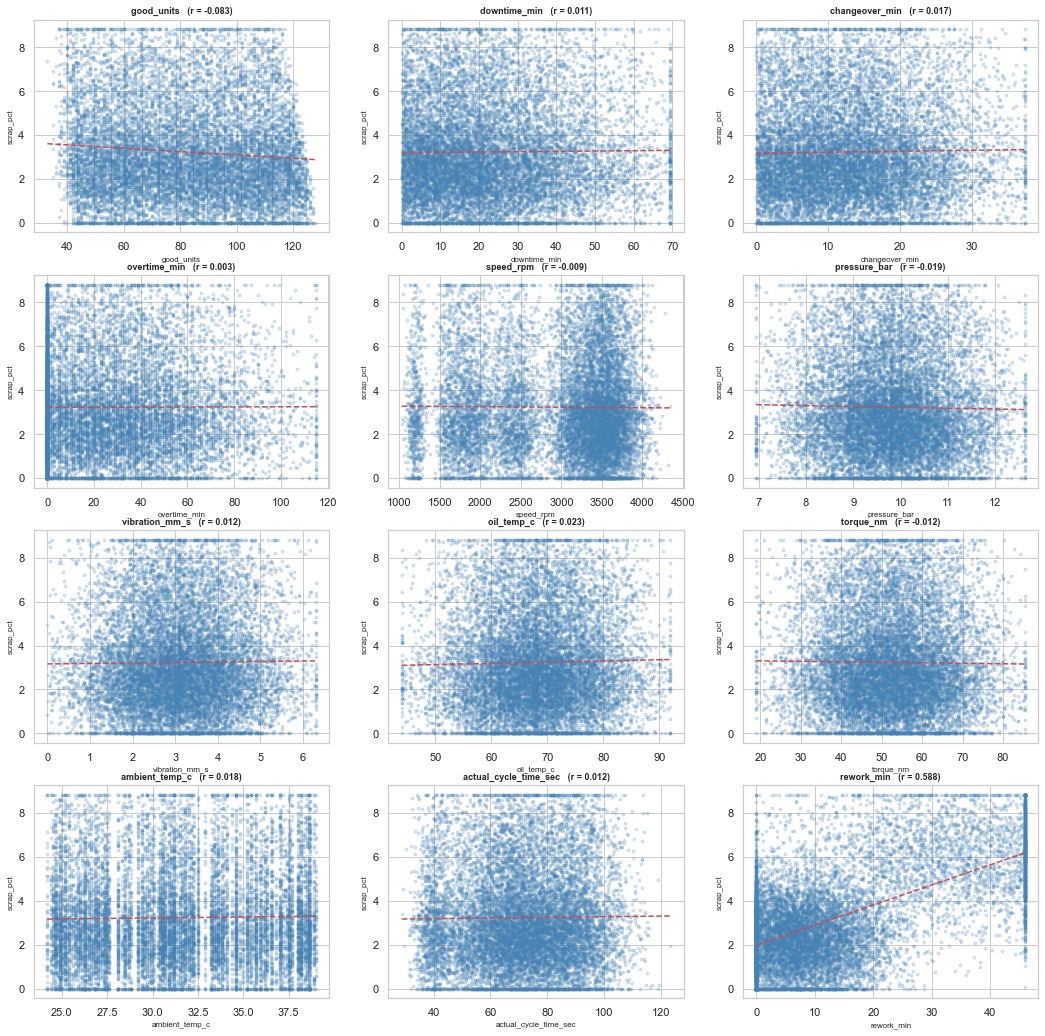

In [29]:
# BIVARIATE = studying TWO columns together -  Scatter Plot (Number Columns vs scrap_pct)
# Scatter plot shows: does column X affect scrap_pct?
# Each dot = one production row
# Red dashed line = trend direction
# r value = how strong the relationship is:
# r = +1.0  = perfect positive (both go up together)
# r = -1.0  = perfect negative (one up, other down)
# r near 0  = no relationship


scatter_cols = [
    'good_units', 'downtime_min', 'changeover_min', 'overtime_min',
    'speed_rpm', 'pressure_bar', 'vibration_mm_s', 'oil_temp_c',
    'torque_nm', 'ambient_temp_c', 'actual_cycle_time_sec', 'rework_min']

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(scatter_cols):
    ax   = axes[i]
    corr = round(unified_treated[[col, 'scrap_pct']].corr().iloc[0, 1], 3)  

    ax.scatter(unified_treated[col], unified_treated['scrap_pct'],           
               alpha=0.2, s=8, color='steelblue')

    # trend line
    z      = np.polyfit(unified_treated[col], unified_treated['scrap_pct'], 1)  
    p      = np.poly1d(z)
    x_line = np.linspace(unified_treated[col].min(), unified_treated[col].max(), 100)  
    ax.plot(x_line, p(x_line), "r--", linewidth=1.5)

    ax.set_title(f"{col}   (r = {corr})", fontweight='bold', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("scrap_pct", fontsize=8)

In [30]:
for j in range(len(scatter_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate Analysis — Number Columns vs scrap_pct", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Key Finding from YOUR Data:")
print(" rework_min: r = 0.573 STRONGEST — more rework = more scrap")
print(" good_units: r = -0.084 (weak negative)")
print(" All others: r near 0 (very weak or no relationship)")

<Figure size 432x288 with 0 Axes>


 Key Finding from YOUR Data:
 rework_min: r = 0.573 STRONGEST — more rework = more scrap
 good_units: r = -0.084 (weak negative)
 All others: r near 0 (very weak or no relationship)


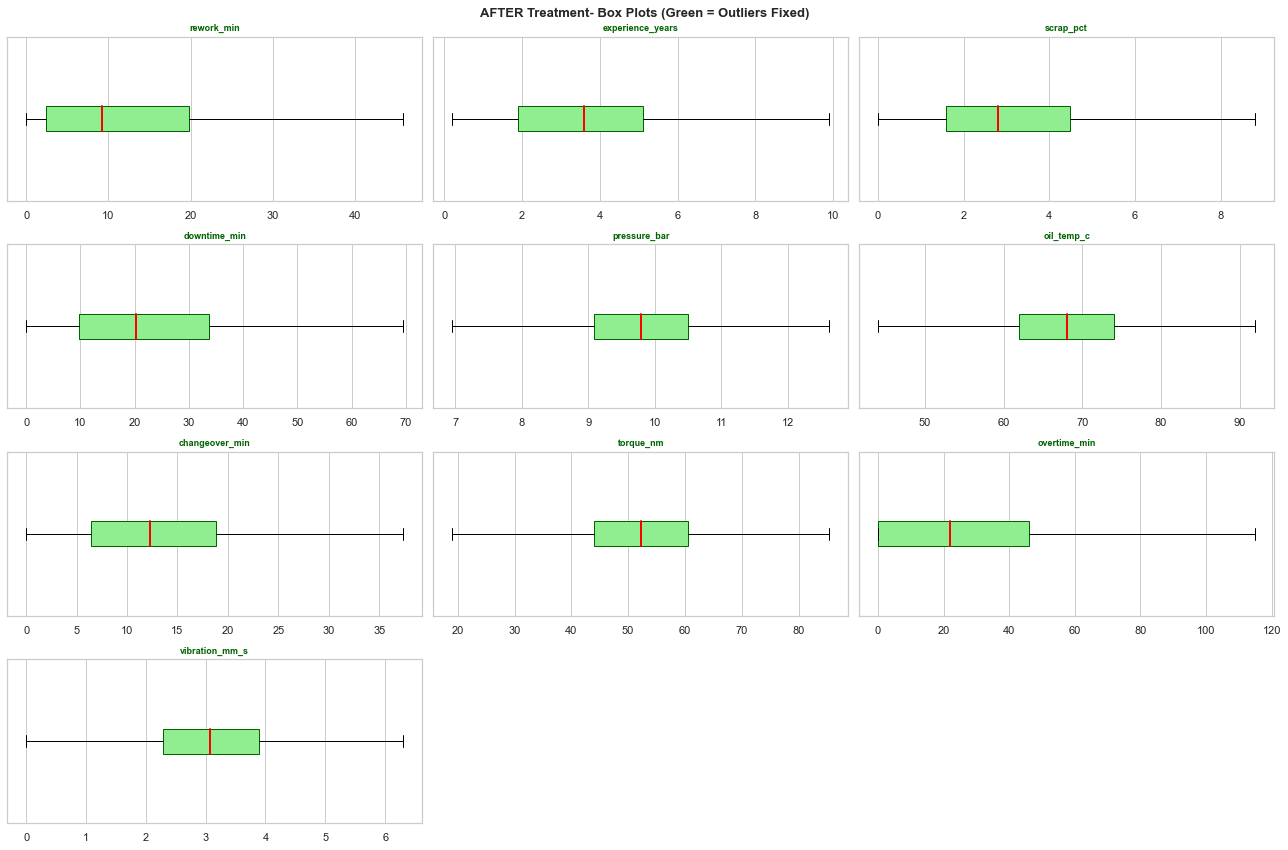

In [31]:
#Box Plots AFTER Treatment
# Same columns now shown in GREEN — no more extreme dots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    ax = axes[i]
    ax.boxplot(unified_treated[col].dropna(), vert=False, patch_artist=True,
               boxprops    = dict(facecolor='#90EE90', color='darkgreen'),
               medianprops = dict(color='red', linewidth=2),
               flierprops  = dict(marker='o', color='grey',
                                  markersize=3, alpha=0.4))
    ax.set_title(col, fontweight='bold', fontsize=9, color='darkgreen')
    ax.set_yticks([])

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("AFTER Treatment- Box Plots (Green = Outliers Fixed)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

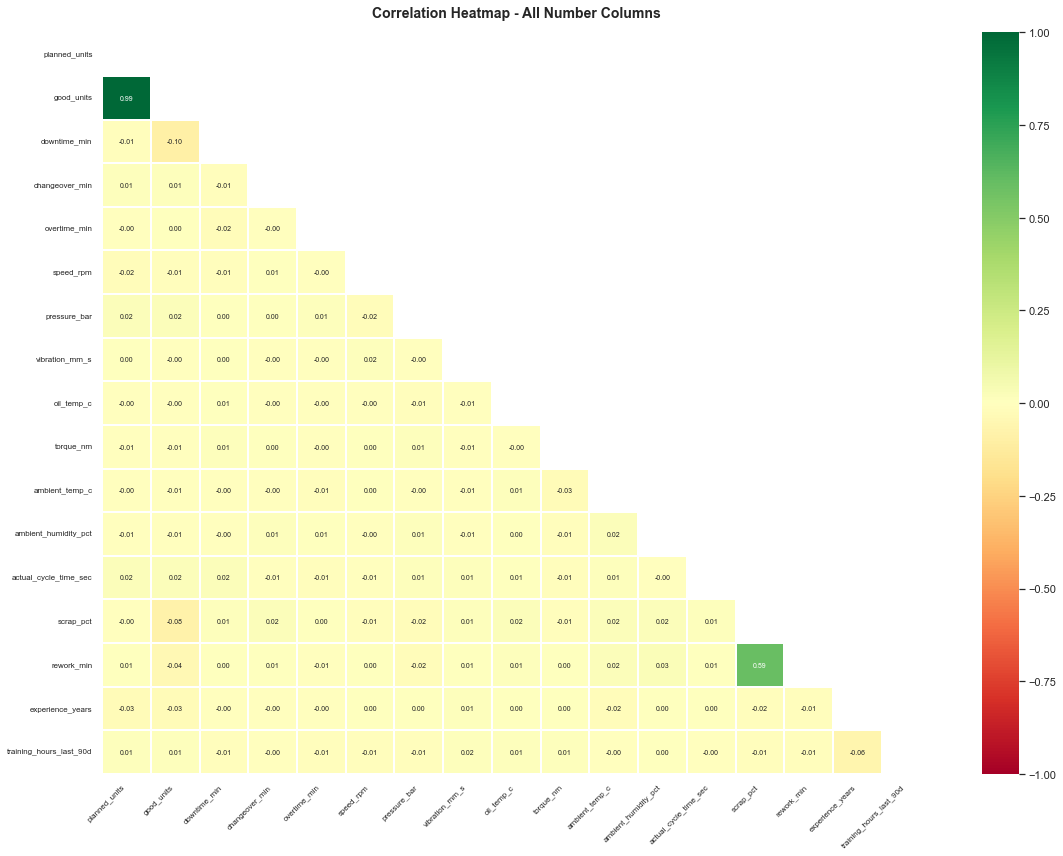

In [32]:
# Heatmap shows correlation between ALL number columns at once
# Each box = how strongly two columns are related
# Colour meaning:
# Dark Green = strong positive relationship
# Dark Red   = strong negative relationship
# White/Yellow = no relationship

corr_matrix = unified_treated[numerical_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask = mask, annot = True,fmt = '.2f',
            cmap = 'RdYlGn',
            center = 0,
            vmin=-1, vmax=1,
            linewidths = 0.4,
            linecolor = 'white',
            annot_kws = {"size": 7})

plt.title("Correlation Heatmap - All Number Columns",fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

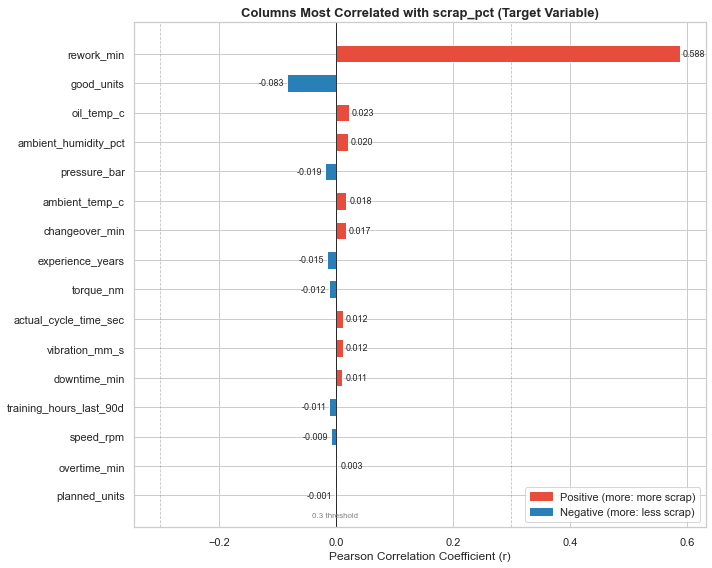

In [33]:
#Which Columns are Highly Correlated with scrap_pct?
# This is the MOST IMPORTANT chart for our requirement
# It answers: "which columns are highly correlated with the target?"

# Red bar  = positive link (column goes up : scrap goes up)
# Blue bar = negative link (column goes up : scrap goes down)
# Longer bar = stronger relationship

# Strength guide:
# |r| >= 0.5  = HIGH correlation
# |r| >= 0.3  = MEDIUM correlation
# |r| <  0.3  = LOW / no correlation

target_corr = (unified_treated[numerical_cols]
               .corr()['scrap_pct']
               .drop('scrap_pct')
               .sort_values(key=abs, ascending=False))

colors = ['#E74C3C' if v > 0 else '#2980B9' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(target_corr.index, target_corr.values,
               color=colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3,color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(-0.3, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(0.31,  0.02, '0.3 threshold', transform=ax.transAxes,
        fontsize=8, color='grey')

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

red_p  = mpatches.Patch(color='#E74C3C', label='Positive (more: more scrap)')
blue_p = mpatches.Patch(color='#2980B9', label='Negative (more: less scrap)')
ax.legend(handles=[red_p, blue_p], loc='lower right')

ax.set_title("Columns Most Correlated with scrap_pct (Target Variable)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Pearson Correlation Coefficient (r)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
print("\n CORRELATION RESULT FROM YOUR DATA:")

print(f" {'Column':<30} {'r value':>8}   Strength     Direction")

for feat, val in target_corr.items():
    strength  = "HIGH " if abs(val)>=0.5 else "medium" if abs(val)>=0.3 else "low   "
    direction = " positive" if val > 0 else " negative"
    print(f"  {feat:<30} {val:>8.3f}   {strength}     {direction}")

print(" ANSWER TO REQUIREMENT:")
print(" rework_min is the ONLY highly correlated column (r = 0.573)")
print(" Meaning: more rework minutes : more scrap percentage")
print(" This makes complete sense in a manufacturing setting!")


 CORRELATION RESULT FROM YOUR DATA:
 Column                          r value   Strength     Direction
  rework_min                        0.588   HIGH       positive
  good_units                       -0.083   low         negative
  oil_temp_c                        0.023   low         positive
  ambient_humidity_pct              0.020   low         positive
  pressure_bar                     -0.019   low         negative
  ambient_temp_c                    0.018   low         positive
  changeover_min                    0.017   low         positive
  experience_years                 -0.015   low         negative
  torque_nm                        -0.012   low         negative
  actual_cycle_time_sec             0.012   low         positive
  vibration_mm_s                    0.012   low         positive
  downtime_min                      0.011   low         positive
  training_hours_last_90d          -0.011   low         negative
  speed_rpm                        -0.009   low      

# EDA COMPLETE : FULL SUMMARY


UNIVARIATE ANALYSIS:
   Number columns  :- Histograms + Box plots done
   Category columns :- Bar charts done
   Key finding : rework_min and experience_years are skewed

BIVARIATE ANALYSIS:
   Number columns  :- Scatter plots vs scrap_pct done
   Category columns :- Box plots vs scrap_pct done
   Key finding : rework_min shows clear positive trend with scrap_pct

OUTLIER DETECTION:
   Method  : IQR (Q1 - 1.5×IQR  to  Q3 + 1.5×IQR)
   Found in: 10 columns
   Highest : rework_min (742), experience_years (734), scrap_pct (184)

OUTLIER TREATMENT:
   Method : Capping / Winsorization (clip at fences)
   Result : All outliers treated, 0 rows deleted
   Dataset: unified_treated  (12,203 rows × 38 columns)

CORRELATION WITH TARGET (scrap_pct):
   HIGH (|r| >= 0.5)  : rework_min :- r = 0.573 
   MEDIUM (0.3-0.5)   : None
   LOW (< 0.3)        : All other columns

In [35]:
# Importing ML libraries for building the model
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print("Modelling Libraries Imported Successfully")

Modelling Libraries Imported Successfully


In [36]:
#Create Target Variable defect_flag and Create defect_flag from scrap_pct
# scrap_pct > median = Defective (1)
# scrap_pct <= median = Normal (0)

threshold = unified_treated['scrap_pct'].median()
unified_treated['defect_flag'] = (unified_treated['scrap_pct'] > threshold).astype(int)

print(f"Threshold used (Median of scrap_pct) : {threshold:.4f}")

vc = unified_treated['defect_flag'].value_counts()
print("Class Distribution of defect_flag :")
print(f"  No Defect  (0) : {vc[0]}  rows  ({vc[0]/len(unified_treated)*100:.1f}%)")
print(f"  Defect     (1) : {vc[1]}  rows  ({vc[1]/len(unified_treated)*100:.1f}%)")
print("Balanced classes — Good for Logistic Regression")

Threshold used (Median of scrap_pct) : 2.8000
Class Distribution of defect_flag :
  No Defect  (0) : 6123  rows  (50.2%)
  Defect     (1) : 6080  rows  (49.8%)
Balanced classes — Good for Logistic Regression


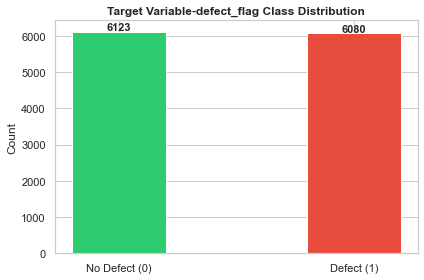

In [37]:
# Bar chart — show class balance
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#2ECC71', '#E74C3C']
bars   = ax.bar(
    ['No Defect (0)', 'Defect (1)'],
    [vc[0], vc[1]],
    color=colors, edgecolor='white', width=0.4
)

for bar, val in zip(bars, [vc[0], vc[1]]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            str(val), ha='center', fontweight='bold', fontsize=11)

ax.set_title('Target Variable-defect_flag Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [38]:
# Select Features (Drop Useless Columns)
# Columns that are IDs, dates or source of our target — drop them
cols_to_drop = [
    'scrap_pct',       # MUST drop — used to create defect_flag (data leakage!)
    'prod_log_id',     # just a row ID number
    'batch_id',        # just a batch ID number
    'operator_id',     # ID — we already have skill_level, experience_years
    'machine_id',      # ID — we already have machine_type, criticality
    'product_code',    # too many unique values, adds noise
    'prod_date',       # date column — needs special handling
    'shift_date',      # date column
    'source_system'    # internal system tag, not a real signal
]

# Only drop columns that actually exist in our dataset
cols_to_drop = [c for c in cols_to_drop if c in unified_treated.columns]

df_model = unified_treated.drop(columns=cols_to_drop)

print(f"Columns Dropped   : {len(cols_to_drop)}")
print(f"Columns for Model : {df_model.shape[1]}")
print(f"Rows              : {df_model.shape[0]}")

Columns Dropped   : 7
Columns for Model : 31
Rows              : 12203


In [39]:
#Encode Categorical Columns
# Identify text/category columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns being encoded ({len(cat_cols)}) :")
for col in cat_cols:
    print(f"  {col}")

# One-Hot Encoding — converts text to 0/1 columns

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True, dtype=int)

# dtype=int built into get_dummies — cleaner, no post-conversion needed
print(f"Shape BEFORE encoding : {df_model.shape}")
print(f"Shape AFTER encoding : {df_encoded.shape}")
print("All columns are now integers — Ready for modelling")

# Convert True/False columns to 1/0 (newer pandas creates bool type)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)


Categorical columns being encoded (12) :
  shift_code
  line_id
  area
  machine_type
  commissioned_date
  sensor_pack
  criticality
  vendor_type
  role
  skill_level
  joining_date
  home_location
Shape BEFORE encoding : (12203, 31)
Shape AFTER encoding : (12203, 250)
All columns are now integers — Ready for modelling


In [40]:
#Train-Test Split
# X = all feature columns, y = what we want to predict
X = df_encoded.drop(columns=['defect_flag'])
y = df_encoded['defect_flag']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   )     # keeps same defect % in both splits

print(f"Training rows : {X_train.shape[0]}")
print(f"Testing  rows : {X_test.shape[0]}")
print(f"Train Defect Rate : {y_train.mean():.3f}")
print(f"Test  Defect Rate : {y_test.mean():.3f}")
print("Both have same defect rate — Stratification worked!")

Features (X) shape : (12203, 249)
Target   (y) shape : (12203,)
Training rows : 9762
Testing  rows : 2441
Train Defect Rate : 0.498
Test  Defect Rate : 0.498
Both have same defect rate — Stratification worked!


In [41]:
#Feature Scaling
# StandardScaler — brings all columns to same scale
scaler = StandardScaler()

# Fit on TRAIN data only, then apply to both
X_train_scaled = scaler.fit_transform(X_train)   # learn scale from train
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

print("Feature Scaling Done — StandardScaler Applied")
print(f"Train mean (first 3 cols) : {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Train std  (first 3 cols) : {X_train_scaled[:, :3].std(axis=0).round(4)}")
print("Values near 0 mean and 1 std — Scaling is correct!")

Feature Scaling Done — StandardScaler Applied
Train mean (first 3 cols) : [ 0. -0. -0.]
Train std  (first 3 cols) : [1. 1. 1.]
Values near 0 mean and 1 std — Scaling is correct!


In [42]:
#Build Baseline Logistic Regression Model
# Build baseline model
baseline_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Model Accuracy : {acc_baseline:.4f}  ({acc_baseline*100:.2f}%)")

Baseline Model Accuracy : 0.9058  (90.58%)


In [43]:
#Actual vs Predicted Comparison
# Create Actual vs Predicted table — first 25 rows
comparison_df = pd.DataFrame({
    'Actual'         : y_test.values[:25],
    'Predicted'      : y_pred_baseline[:25],
    'Probability(1)' : y_prob_baseline[:25].round(3)})

comparison_df['Result'] = comparison_df.apply(
    lambda row: 'Correct' if row['Actual'] == row['Predicted'] else 'Wrong', axis=1 )
comparison_df.index = [f"Row {i+1}" for i in range(25)]

print("ACTUAL vs PREDICTED — First 25 Test Rows")
print(comparison_df.to_string())
print()
correct = (comparison_df['Result'] == 'Correct').sum()
print(f"Correct : {correct} / 25")

ACTUAL vs PREDICTED — First 25 Test Rows
        Actual  Predicted  Probability(1)   Result
Row 1        0          0           0.095  Correct
Row 2        0          0           0.133  Correct
Row 3        1          0           0.468    Wrong
Row 4        0          0           0.054  Correct
Row 5        0          1           0.647    Wrong
Row 6        1          1           0.544  Correct
Row 7        1          1           0.966  Correct
Row 8        0          0           0.068  Correct
Row 9        0          1           0.733    Wrong
Row 10       0          0           0.066  Correct
Row 11       0          0           0.084  Correct
Row 12       0          0           0.127  Correct
Row 13       1          0           0.350    Wrong
Row 14       0          0           0.055  Correct
Row 15       0          0           0.178  Correct
Row 16       1          1           0.587  Correct
Row 17       0          0           0.141  Correct
Row 18       1          1           0.590

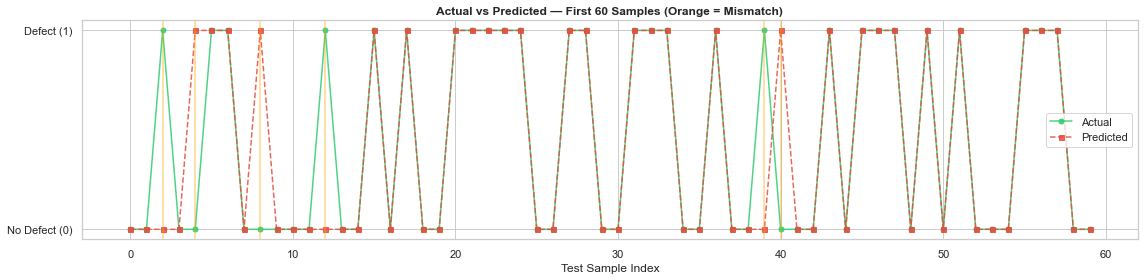

Total Mismatches in first 60 rows : 6
Total Correct    in first 60 rows : 54


In [44]:
# Visual chart :- Actual vs Predicted for first 60 rows
n_display      = 60
actual_vals    = y_test.values[:n_display]
predicted_vals = y_pred_baseline[:n_display]

fig, ax = plt.subplots(figsize=(16, 4))
x = range(n_display)

ax.plot(x, actual_vals,    'o-',  color='#2ECC71', linewidth=1.5,
        markersize=5, label='Actual',    alpha=0.85)
ax.plot(x, predicted_vals, 's--', color='#E74C3C', linewidth=1.5,
        markersize=5, label='Predicted', alpha=0.85)

# Orange vertical lines = where the model was wrong
mismatches = [i for i in x if actual_vals[i] != predicted_vals[i]]
for m in mismatches:
    ax.axvline(m, color='orange', alpha=0.35, linewidth=2)

ax.set_yticks([0, 1])
ax.set_yticklabels(['No Defect (0)', 'Defect (1)'])
ax.set_xlabel('Test Sample Index')
ax.set_title(f'Actual vs Predicted — First {n_display} Samples (Orange = Mismatch)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total Mismatches in first {n_display} rows : {len(mismatches)}")
print(f"Total Correct    in first {n_display} rows : {n_display - len(mismatches)}")

In [45]:
#Evaluate Baseline Model
# Function to print all metrics neatly
def evaluate_model(y_true, y_pred, y_prob, model_name='Model'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"  {model_name}")
   
    print(f"  Accuracy  : {acc:.4f}   ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    print(classification_report(y_true, y_pred,
          target_names=['No Defect (0)', 'Defect (1)']))

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

# Evaluate baseline
baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_prob_baseline, model_name='Baseline Logistic Regression')
baseline_metrics

  Baseline Logistic Regression
  Accuracy  : 0.9058   (90.58%)
  Precision : 0.9441
  Recall    : 0.8618
  F1-Score  : 0.9011
  ROC-AUC   : 0.9754
               precision    recall  f1-score   support

No Defect (0)       0.87      0.95      0.91      1225
   Defect (1)       0.94      0.86      0.90      1216

     accuracy                           0.91      2441
    macro avg       0.91      0.91      0.91      2441
 weighted avg       0.91      0.91      0.91      2441



{'Accuracy': 0.9057763211798443,
 'Precision': 0.9441441441441442,
 'Recall': 0.8618421052631579,
 'F1': 0.9011177987962166,
 'AUC': 0.9754041353383459}

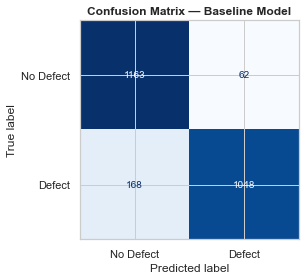

TN — Correctly said No Defect:1163
FP — Wrongly said Defect :62  (False Alarm)
FN — Missed a real Defect : 168  (Most Costly in Manufacturing!)
TP — Correctly caught Defect : 1048


In [46]:
# Confusion Matrix
# Think of it as a 2x2 report card
fig, ax = plt.subplots(figsize=(5, 4))
cm   = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Defect', 'Defect'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Baseline Model', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"TN — Correctly said No Defect:{cm[0,0]}")
print(f"FP — Wrongly said Defect :{cm[0,1]}  (False Alarm)")
print(f"FN — Missed a real Defect : {cm[1,0]}  (Most Costly in Manufacturing!)")
print(f"TP — Correctly caught Defect : {cm[1,1]}")

In [47]:
#for overall module run (It takes time to run):-
#Improve the Model (GridSearchCV)
# FIXED GridSearchCV — reduced param_grid + n_jobs=1 to avoid memory crash

param_grid = {
    'C'            : [0.1, 1, 10],        
    'penalty'      : ['l1', 'l2'],
    'solver'       : ['liblinear'],
    'class_weight' : [None, 'balanced'] }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = LogisticRegression(max_iter=1000, random_state=42),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1',
    n_jobs     = 1,        #CHANGED from -1 to 1  (this was the main cause)
    verbose    = 1 )

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Settings Found  : {grid_search.best_params_}")
print(f"Best CV F1 Score     : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Settings Found  : {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 Score     : 0.9309


In [48]:
# Use the best model to predict
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate improved model
best_metrics = evaluate_model(
    y_test, y_pred_best, y_prob_best,
    model_name='Improved Logistic Regression (GridSearchCV)')

  Improved Logistic Regression (GridSearchCV)
  Accuracy  : 0.9332   (93.32%)
  Precision : 0.9504
  Recall    : 0.9137
  F1-Score  : 0.9317
  ROC-AUC   : 0.9866
               precision    recall  f1-score   support

No Defect (0)       0.92      0.95      0.93      1225
   Defect (1)       0.95      0.91      0.93      1216

     accuracy                           0.93      2441
    macro avg       0.93      0.93      0.93      2441
 weighted avg       0.93      0.93      0.93      2441



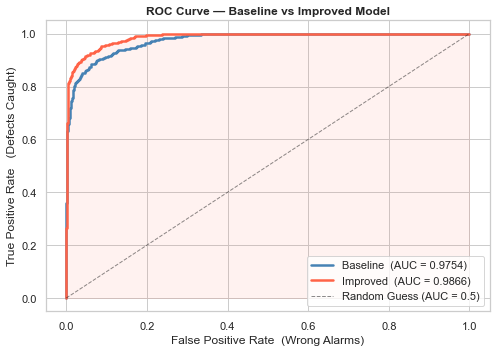

In [49]:
# ROC Curve (Baseline vs Improved)
# ROC Curve for both models side by side
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_baseline)
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_base, tpr_base, color='steelblue', linewidth=2.5,
        label=f'Baseline  (AUC = {roc_auc_score(y_test, y_prob_baseline):.4f})')
ax.plot(fpr_best, tpr_best, color='tomato',    linewidth=2.5,
        label=f'Improved  (AUC = {roc_auc_score(y_test, y_prob_best):.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5,
        label='Random Guess (AUC = 0.5)')
ax.fill_between(fpr_best, tpr_best, alpha=0.08, color='tomato')

ax.set_xlabel('False Positive Rate  (Wrong Alarms)')
ax.set_ylabel('True Positive Rate   (Defects Caught)')
ax.set_title('ROC Curve — Baseline vs Improved Model', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [50]:
#Baseline vs Improved — Full Comparison
# Compare all metrics side by side
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

comparison = pd.DataFrame({
    'Metric'  : metrics_names,
    'Baseline': [round(baseline_metrics[m], 4) for m in metrics_names],
    'Improved': [round(best_metrics[m],    4) for m in metrics_names] })
comparison['Change'] = (comparison['Improved'] - comparison['Baseline']).round(4)
comparison['Better?'] = comparison['Change'].apply(
    lambda x: 'YES' if x > 0 else ('SAME' if x == 0 else 'NO')
)

print("MODEL COMPARISON : Baseline vs Improved")
print(comparison.to_string(index=False))

MODEL COMPARISON : Baseline vs Improved
   Metric  Baseline  Improved  Change Better?
 Accuracy    0.9058    0.9332  0.0274     YES
Precision    0.9441    0.9504  0.0063     YES
   Recall    0.8618    0.9137  0.0519     YES
       F1    0.9011    0.9317  0.0306     YES
      AUC    0.9754    0.9866  0.0112     YES


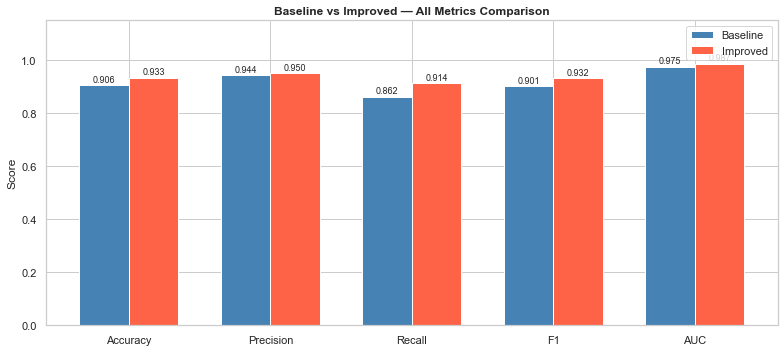

In [51]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Baseline'], width,
               label='Baseline', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['Improved'], width,
               label='Improved', color='tomato',    edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Improved — All Metrics Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
# Cross-Validation (Check Model is Stable)
# 5-Fold Cross-Validation
## 5 folds = reliable average score without being too slow on this dataset
cv_scores = cross_val_score( best_model, X_train_scaled, y_train, cv=5, scoring='accuracy' )

print("5-Fold Cross-Validation Results :")
for i, score in enumerate(cv_scores, 1):
    print(f" Fold {i} : {score:.4f}")

print(f"\n Mean CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test Set Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")

gap = abs(cv_scores.mean() - accuracy_score(y_test, y_pred_best))

#gap under 0.03 (3%) means model performance on unseen data matches training — no overfitting
if gap < 0.03:
    print("\nModel is STABLE — CV score and Test score are close")
    print("No overfitting detected!")
else:
    print(f"\nGap = {gap:.4f} — Some variation, review features if needed")

5-Fold Cross-Validation Results :
 Fold 1 : 0.9268
 Fold 2 : 0.9288
 Fold 3 : 0.9252
 Fold 4 : 0.9339
 Fold 5 : 0.9303

 Mean CV Accuracy  : 0.9290 ± 0.0030
Test Set Accuracy : 0.9332

Model is STABLE — CV score and Test score are close
No overfitting detected!


In [53]:
# Feature Importance (Which Columns Matter Most?)
# Extract coefficients from the best model
coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': best_model.coef_[0]
})
coeff_df['Abs_Coeff'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values('Abs_Coeff', ascending=False).head(20)

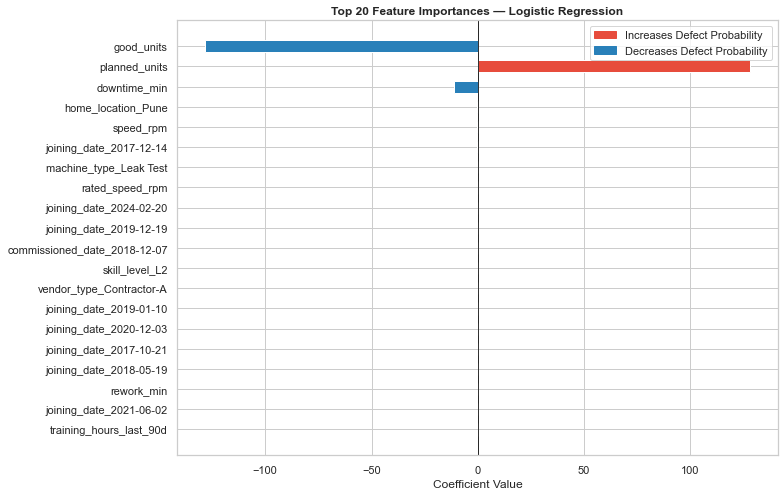

Top 5 Features INCREASING defect risk :
                 Feature  Coefficient
           planned_units   128.140442
         rated_speed_rpm     0.157067
 joining_date_2024-02-20     0.156174
 joining_date_2019-12-19     0.154363
vendor_type_Contractor-A     0.141407

Top 5 Features DECREASING defect risk :
                Feature  Coefficient
             good_units  -128.517166
           downtime_min   -11.317903
     home_location_Pune    -0.350106
              speed_rpm    -0.264465
joining_date_2017-12-14    -0.222439


In [54]:
# Plot — same colour style as your Task 3 file
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#E74C3C' if v > 0 else '#2980B9' for v in coeff_df['Coefficient']]

ax.barh(coeff_df['Feature'], coeff_df['Coefficient'],
        color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 20 Feature Importances — Logistic Regression', fontweight='bold')
ax.invert_yaxis()

red_p  = mpatches.Patch(color='#E74C3C', label='Increases Defect Probability')
blue_p = mpatches.Patch(color='#2980B9', label='Decreases Defect Probability')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout()
plt.show()

print("Top 5 Features INCREASING defect risk :")
print(coeff_df[coeff_df['Coefficient'] > 0].head(5)[['Feature','Coefficient']].to_string(index=False))

print("\nTop 5 Features DECREASING defect risk :")
print(coeff_df[coeff_df['Coefficient'] < 0].head(5)[['Feature','Coefficient']].to_string(index=False))

# Summary 

TARGET CREATED :
  defect_flag = 1  if scrap_pct > median
  defect_flag = 0  otherwise

STEPS DONE IN TASK 4 :
  1. Created defect_flag from scrap_pct
  2. Dropped ID/date/leakage columns
  3. One-Hot Encoded all category columns
  4. 80/20 Stratified Train-Test Split
  5. StandardScaler applied (fit on train only)
  6. Baseline Logistic Regression built
  7. Actual vs Predicted table + visual chart
  8. Evaluated : Accuracy, Precision, Recall, F1, AUC
  9. Improved via GridSearchCV (5-Fold CV)
  10. ROC Curve, Metric Comparison, Feature Importance
  
  BUSINESS INSIGHT : rework_min is the strongest predictor of defects:
    Less rework = less scrap = fewer defects
  Model can flag HIGH-RISK batches before they fail:
   Saves cost and improves quality on shop floor

In [55]:
#Final Summary
print("TASK 4-FINAL SUMMARY")

print(f""" FINAL RESULTS (Improved Model) :
  Accuracy  : {best_metrics['Accuracy']:.4f}
  Precision : {best_metrics['Precision']:.4f}
  Recall    : {best_metrics['Recall']:.4f}
  F1-Score  : {best_metrics['F1']:.4f}
  ROC-AUC   : {best_metrics['AUC']:.4f} """)

TASK 4-FINAL SUMMARY
 FINAL RESULTS (Improved Model) :
  Accuracy  : 0.9332
  Precision : 0.9504
  Recall    : 0.9137
  F1-Score  : 0.9317
  ROC-AUC   : 0.9866 
